In [21]:
import pandas as pd
import numpy as np

In [22]:
df = pd.read_csv("../data/results.csv")

In [23]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        49071 non-null  str  
 1   home_team   49071 non-null  str  
 2   away_team   49071 non-null  str  
 3   home_score  49071 non-null  int64
 4   away_score  49071 non-null  int64
 5   tournament  49071 non-null  str  
 6   city        49071 non-null  str  
 7   country     49071 non-null  str  
 8   neutral     49071 non-null  bool 
dtypes: bool(1), int64(2), str(6)
memory usage: 3.0 MB


In [25]:
df.describe()

,home_score,away_score
count,49071.000000,49071.000000
mean,1.756272,1.182185
std,1.771367,1.401572
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [26]:
df.shape

(49071, 9)

In [27]:
df["date"].min()

'1872-11-30'

In [28]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')

In [29]:
df['country'].nunique()

269

In [30]:
df['home_team'].value_counts()

home_team
Brazil              610
Argentina           599
Mexico              596
Germany             552
South Korea         549
                   ... 
Elba Island           1
West Papua            1
Ticino                1
Hmong                 1
Marshall Islands      1
Name: count, Length: 325, dtype: int64

In [31]:
df['home_team'].value_counts().idxmax()

'Brazil'

In [32]:
english_soccer = df[
    ((df['home_team'] == 'England') & (df['away_team'] == 'Scotland')) |
    ((df['home_team'] == 'Scotland') & (df['away_team'] == 'England'))
]

english_soccer['year'] = pd.to_datetime(english_soccer['date']).dt.year

english_soccer.groupby('year').size()

year
1872    1
1873    1
1874    1
1875    1
1876    1
       ..
2014    1
2016    1
2017    1
2021    1
2023    1
Length: 115, dtype: int64

In [33]:
df["total_goals"] = df["home_score"] + df["away_score"]

In [34]:
df["total_goals"].mean()

np.float64(2.938456522182144)

In [35]:
df["total_goals"].max()

np.int64(31)

In [36]:
df.loc[df["total_goals"].idxmax()]

date                             2001-04-11
home_team                         Australia
away_team                    American Samoa
home_score                               31
away_score                                0
tournament     FIFA World Cup qualification
city                          Coffs Harbour
country                           Australia
neutral                               False
total_goals                              31
Name: 25420, dtype: object

In [40]:
home_goals = df["home_score"].sum()
away_goals = df["away_score"].sum()
home_goals, away_goals

np.int64(86182)

In [42]:
df["total_goals"].mode()

0    2
Name: total_goals, dtype: int64

In [44]:
df["total_goals"].value_counts()

total_goals
2     10896
3      9703
1      8496
4      6792
5      4228
0      3943
6      2295
7      1250
8       643
9       354
10      185
11       99
12       63
13       36
14       23
15       14
16       13
18       11
17       10
19        5
20        4
21        3
22        2
30        1
24        1
31        1
Name: count, dtype: int64

In [45]:
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)

In [46]:
home_wins = (df["result"] == "Home Win").sum()
total_matches = len(df)

home_win_percentage = (home_wins / total_matches) * 100

print("Home win percentage:", home_win_percentage)

Home win percentage: 48.996352224328014


In [47]:
result_counts = df["result"].value_counts()
print(result_counts)

result
Home Win    24043
Away Win    13872
Draw        11156
Name: count, dtype: int64


In [48]:
result_percent = df["result"].value_counts(normalize=True) * 100
print(result_percent)

result
Home Win    48.996352
Away Win    28.269243
Draw        22.734405
Name: proportion, dtype: float64


In [49]:
home_winners = df[df["result"] == "Home Win"]["home_team"]
away_winners = df[df["result"] == "Away Win"]["away_team"]

all_wins = pd.concat([home_winners, away_winners])

team_wins = all_wins.value_counts()

print(team_wins.head(10))

Brazil         669
England        623
Germany        595
Argentina      586
Sweden         539
South Korea    536
Mexico         510
France         474
Italy          474
Hungary        469
Name: count, dtype: int64


In [50]:
print("Team with most wins:", team_wins.idxmax())

Team with most wins: Brazil


In [52]:
import matplotlib.pyplot as plt

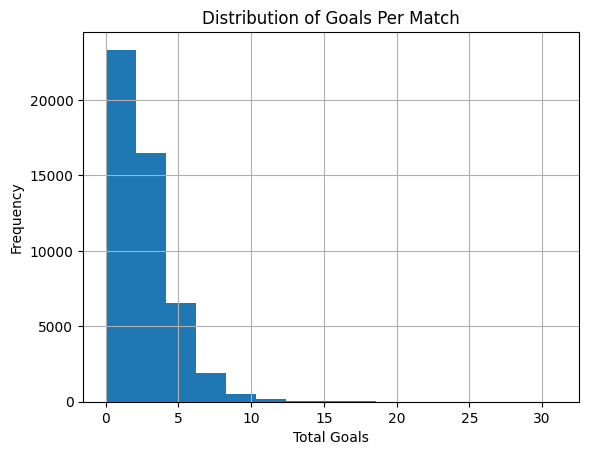

In [53]:
df["total_goals"].hist(bins=15)
plt.title("Distribution of Goals Per Match")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()

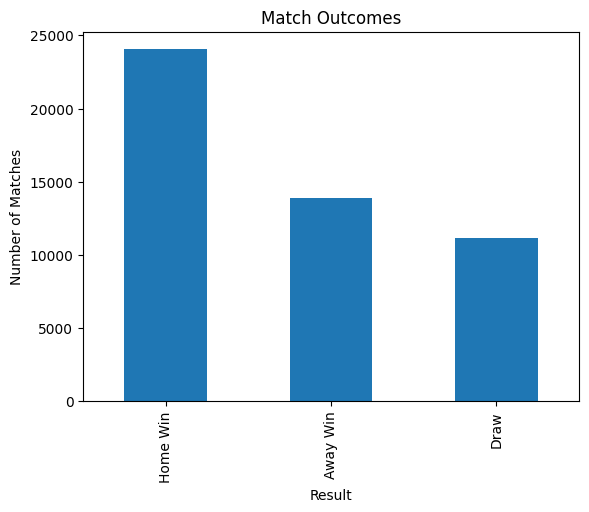

In [54]:
df["result"].value_counts().plot(kind="bar")

plt.title("Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Number of Matches")

plt.show()

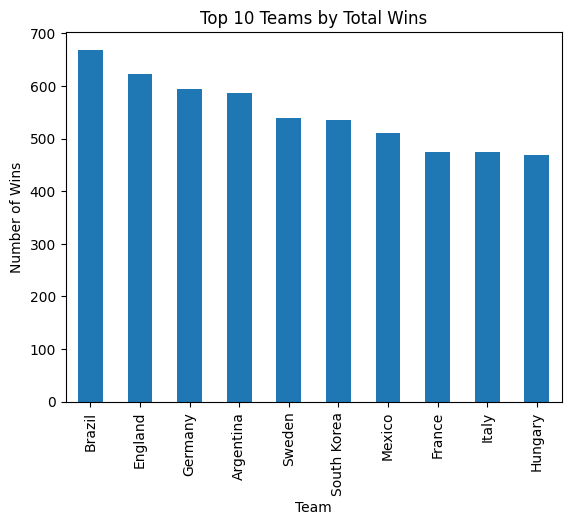

In [55]:
team_wins.head(10).plot(kind="bar")

plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.show()